We need to install the necessary packages.

In [1]:
!pip install -q -U transformers bitsandbytes accelerate xformers datasets peft trl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 MB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.4/293.4 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 8.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires fsspec==2024.10.0, but you have fsspec 2024.9.0 which is incompatible.


You need provide your token since the Llama models are in a gated repository.

In [35]:
device = "cuda"

from google.colab import userdata

HUGGINGFACE_TOKEN = userdata.get("HUGGINGFACE_TOKEN")

In [36]:
from huggingface_hub import login

login(token=HUGGINGFACE_TOKEN)

## Finetuning Llama 3.1 Instruct 1B

The Llama 3.1B instruction tuned model is used. We use 8 bit quantization for faster inference and training. Note that the quantization only works on the GPU.

In [4]:
from transformers import LlamaTokenizer, LlamaForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model

# Load the model and tokenizer
llama_model_name = "meta-llama/Llama-3.2-1B-Instruct"
llama_tokenizer = AutoTokenizer.from_pretrained(llama_model_name)

# If the tokenizer does not have a pad_token, set it manually
if llama_tokenizer.pad_token is None:
    llama_tokenizer.pad_token = "[PAD]"
    llama_tokenizer.add_special_tokens({'pad_token': '[PAD]'})

quantization_config = BitsAndBytesConfig(load_in_8bit=True)  # or load_in_4bit=True if you want 4-bit

llama_model = LlamaForCausalLM.from_pretrained(llama_model_name, device_map="auto", quantization_config=quantization_config)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/877 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

Since it is infeasible to train all the one billion parameters, we use [LoRA](https://arxiv.org/pdf/2106.09685) for instruction tuning. This means we only need to train a small number of additional low-rank matrices, while keeping the original model's weights frozen.

In [5]:
from peft import prepare_model_for_kbit_training, get_peft_model

# Configure LoRA
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)

prepared_model = prepare_model_for_kbit_training(llama_model)
qlora_model = get_peft_model(prepared_model, lora_config)

We can test the loaded model by asking it some medical question. For instance:
- What types of bacterial infections is penicillin commonly used to treat?
- Which organ is primarily responsible for maintaining acid-base balance in the body?
- Which molecule is the primary source of energy for cellular metabolism?
- Which type of cell is responsible for producing antibodies?

In [37]:
def chat(model, tokenizer):
  while True:
      # Interactive input from the user
      question = input("Enter your question (or type 'exit' to quit): ")
      if question.lower() == 'exit':
          print("Exiting the assistant.")
          break

      # Prepare the input text
      input_text = (
          f"<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\n"
          "You are a helpful assistant<|eot_id|><|start_header_id|>user<|end_header_id|>\n\n"
          f"{question}<|eot_id|><|start_header_id|>assistant<|end_header_id|>"
      )

      # Tokenize the input text and specify pad_token_id and attention_mask
      inputs = tokenizer(input_text, return_tensors="pt", padding=True, truncation=True).to(device)

      # Ensure the attention_mask and pad_token_id are set
      attention_mask = inputs.get("attention_mask", None)
      pad_token_id = tokenizer.pad_token_id  # Use the tokenizer's default pad_token_id

      # Perform inference (generate predictions)
      outputs = model.generate(
          inputs["input_ids"], attention_mask=attention_mask, max_length=512, num_return_sequences=1, pad_token_id=pad_token_id
      )

      # Decode the generated text
      generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)

      # Extract only the assistant's response by removing the prompt
      # Note that the special tokens are skipped in the text
      if question in generated_text:
          assistant_response = generated_text.split(question+"assistant", 1)[-1].strip()
      else:
          assistant_response = generated_text.strip()

      print("\n")
      print(assistant_response)
      print("--------------------------------------------------------------------------")

In [38]:
chat(qlora_model, llama_tokenizer)

Enter your question (or type 'exit' to quit): Which organ is primarily responsible for maintaining acid-base balance in the body?


/usr/local/lib/python3.10/dist-packages/bitsandbytes/autograd/_functions.py:315: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")




The kidneys are primarily responsible for maintaining acid-base balance in the body. They play a crucial role in regulating the body's acid-base balance by controlling the levels of hydrogen ions (H+) in the blood.

The kidneys filter waste products from the blood and remove excess hydrogen ions, which are acidic, to help maintain the body's acid-base balance. They also produce bicarbonate, a base, to help maintain the body's pH levels.

The kidneys' role in acid-base balance is often referred to as the "acid-base regulation" or "renal acidosis." They work in conjunction with other organs, such as the lungs, liver, and brain, to maintain a stable acid-base balance.

Here's a simplified explanation of the process:

1. The kidneys filter waste products from the blood, including excess hydrogen ions.
2. The kidneys produce bicarbonate, a base, to help neutralize excess hydrogen ions.
3. The kidneys excrete excess bicarbonate into the urine, which helps to maintain the body's acid-base b

KeyboardInterrupt: Interrupted by user

For instruction tuning we use the medical flashcards dataset from the [medAlpaca](https://arxiv.org/pdf/2304.08247) paper. The dataset consists of Anki medical flashcards created by medicine students that cover the whole medicine curriculum. The authors used OpenAI's GPT-3.5-turbo to convert each flashcard into a question answer pair.

We create a process function so that the data follows the Llama 3.1 1B Instruct [prompt format](https://github.com/meta-llama/llama-models/blob/main/models/llama3_1/prompt_format.md).

In [39]:
from datasets import load_dataset

dataset = load_dataset("medalpaca/medical_meadow_medical_flashcards", split="train")

def preprocess(example):
    txt = [
      f"<|begin_of_text|><|start_header_id|>system<|end_header_id|>\nAnswer this question truthfully.<|eot_id|>\n<|start_header_id|>user<|end_header_id|>\n\n{inp}<|eot_id|>\n<|start_header_id|>assistant<|end_header_id|>\n{outp}"
      for instruction, inp, outp in zip(example["instruction"], example["input"], example["output"])
    ]
    return txt

Login to wandb to monitor the training.

In [40]:
!wandb login

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit: 
Aborted!
Exception ignored in atexit callback: <function _start_and_connect_service.<locals>.teardown_atexit at 0x78feff18bd00>
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/wandb/sdk/lib/service_connection.py", line 93, in teardown_atexit
    conn.teardown(hooks.exit_code)
  File "/usr/local/lib/python3.10/dist-packages/wandb/sdk/lib/service_connection.py", line 216, in teardown
    return self._proc.join()
  File "/usr/local/lib/python3.10/dist-packages/wandb/sdk/service/service.py", line 241, in join
    ret = self._internal_proc.wait()
  File "/usr/lib/python3.10/subprocess.py", line 1209, in wait
    return self._wait(timeout=timeout)
  File "/usr/lib/python3.10/subprocess.py", li

We can either fine-tune the base model or use the already fine-tuned model available in the $\texttt{llama-3.1_finetuned_model}$ folder.

In [20]:
from transformers import TrainingArguments, Trainer, AutoModelForCausalLM, AutoTokenizer
from trl import SFTConfig, SFTTrainer, DataCollatorForCompletionOnlyLM

import os

USE_SAVED_MODEL = True
MODEL_DIR = "./llama-3.1_finetuned_model"

os.environ["WANDB_PROJECT"] = "advtop-nlp-proj"

training_args = SFTConfig(
    output_dir="./train/llama-medical-flashcards",
    eval_strategy="no",
    learning_rate=2e-5,
    num_train_epochs=3,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=4,
    lr_scheduler_type="cosine",
    warmup_steps=200,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
    save_strategy="steps",
    save_steps=500,
    save_total_limit=2,
    bf16=True,
    push_to_hub=False,
    report_to="wandb",
    max_seq_length=1024,
)

if USE_SAVED_MODEL:
  llama_finetuned_model = AutoModelForCausalLM.from_pretrained(MODEL_DIR, device_map="auto", quantization_config=quantization_config)
  llama_finetuned_tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
else:
  trainer = SFTTrainer(
    qlora_model,
    args=training_args,
    train_dataset=dataset,
    formatting_func=preprocess,
  )
  trainer.train()

  qlora_model.save_pretrained(MODEL_DIR)
  llama_tokenizer.save_pretrained(MODEL_DIR)

In [41]:
chat(llama_finetuned_model, llama_finetuned_tokenizer)

Enter your question (or type 'exit' to quit): Which organ is primarily responsible for maintaining acid-base balance in the body?


The kidneys are primarily responsible for maintaining acid-base balance in the body. They play a crucial role in regulating the levels of hydrogen ions (H+) and bicarbonate (HCO3-) in the blood, which helps to maintain a stable pH level. The kidneys filter waste products and excess fluids from the blood, and also remove excess hydrogen ions (H+) and excess bicarbonate (HCO3-) to maintain acid-base balance. This process is known as acid-base regulation, and it is an important function of the kidneys that helps to keep the body's pH levels within a narrow range.
--------------------------------------------------------------------------


KeyboardInterrupt: Interrupted by user

## Evaluating on Multiple choice

The models' performance was assessed based on their zero-shot capabilities across the United States Medical Licensing Examination (USMLE) Step 1, Step 2, and Step 3 self-assessment datasets. The USMLE is the exam you have to take in the United States for medical licensure. [Wikipedia](https://en.wikipedia.org/wiki/United_States_Medical_Licensing_Examination) provides a description of the different steps:
- Step 1: "Application of scientific principles basic to the practice of medicine"
- Step 2: "Application of medical knowledge, skills, and understanding of clinical science essential for supervised patient care"
- Step 3: "Application of medical knowledge and understanding of biomedical and clinical science essential for the unsupervised practice of medicine"

Depending on the question, there are three to nine options to choose from. One should note that the questions are almost impossible to answer for somebody without a background in medicine.

If a model's output did not conform to the required format, it was prompted up to five times to generate the response correctly. If the model still failed to produce the desired format, the last generated response was retained.

The USMLE dataset is from the [medAlpaca](https://arxiv.org/pdf/2304.08247) paper. The evaluation code below is adapted from the medAlpaca. This allows us to compare our results with theirs. The data set consists of six files. For each step there are two files: one containing the questions and the answer options and a file containing the solutions.

In [24]:
import os
import json

questions_saved = []

for step_idx in range(1, 4):
    with open(f"./eval/step{step_idx}.json") as fp:
        questions = json.load(fp)

        with open(f"./eval/step{step_idx}_solutions.json") as sol_fp:
          solutions = json.load(sol_fp)

        for question in questions:
            if question.get("image") or question.get("image_url"):
              continue

            question_number = str(question["no"])
            solution = None
            if question_number in solutions:
                solution = solutions[question_number]

            num_options = len(question["options"])
            questions_saved.append({
                "question": question["question"],
                "step": step_idx,
                "numberAnswerOptions": num_options,
                "solution": solution
            })

We investigate the distribution of the number of answer options. Most questions have five answer options.

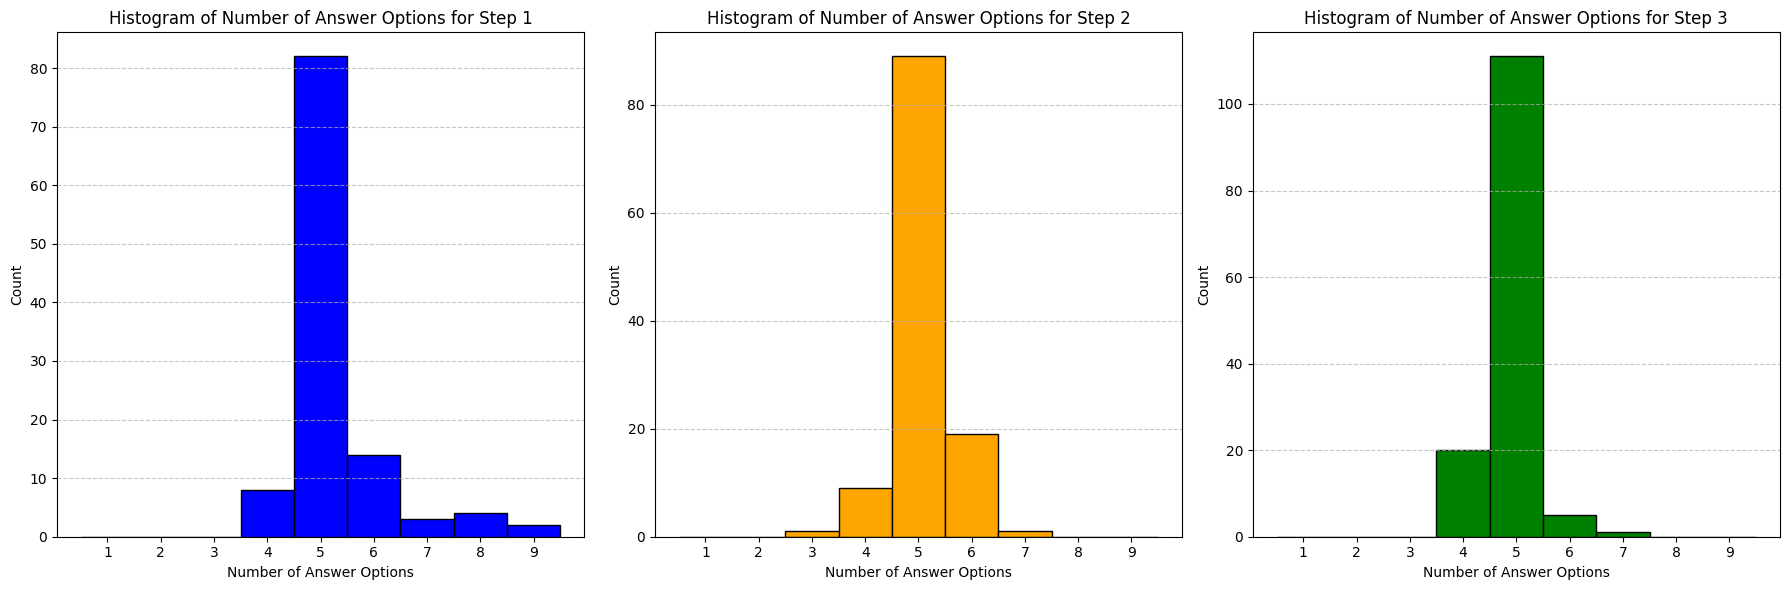

In [42]:
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np

answer_options_by_step = defaultdict(list)

for question in questions_saved:
    step = question["step"]
    num_options = question["numberAnswerOptions"]
    answer_options_by_step[step].append(num_options)

colors = ["blue", "orange", "green"]
labels = [f"Step {i}" for i in range(1, 4)]

# Define the bin edges to center bins on x-axis labels
bin_edges = np.arange(0.5, 10.5, 1)

# Create a single figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot each histogram on its respective subplot
for step_idx, color, label, ax in zip(range(1, 4), colors, labels, axes):
    ax.hist(answer_options_by_step[step_idx], bins=bin_edges,
            alpha=1.0, edgecolor="black", color=color)

    ax.set_xticks(np.arange(1, 10))
    ax.set_xticklabels(np.arange(1, 10))

    ax.set_title(f"Histogram of Number of Answer Options for {label}")
    ax.set_xlabel("Number of Answer Options")
    ax.set_ylabel("Count")
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


Next, the distribution of the solution is investigated. The distribution for the answer options A to E is (very) roughly uniform as expected. Since many questions do not have more than five answers options, options F and G are not frequently the solution.

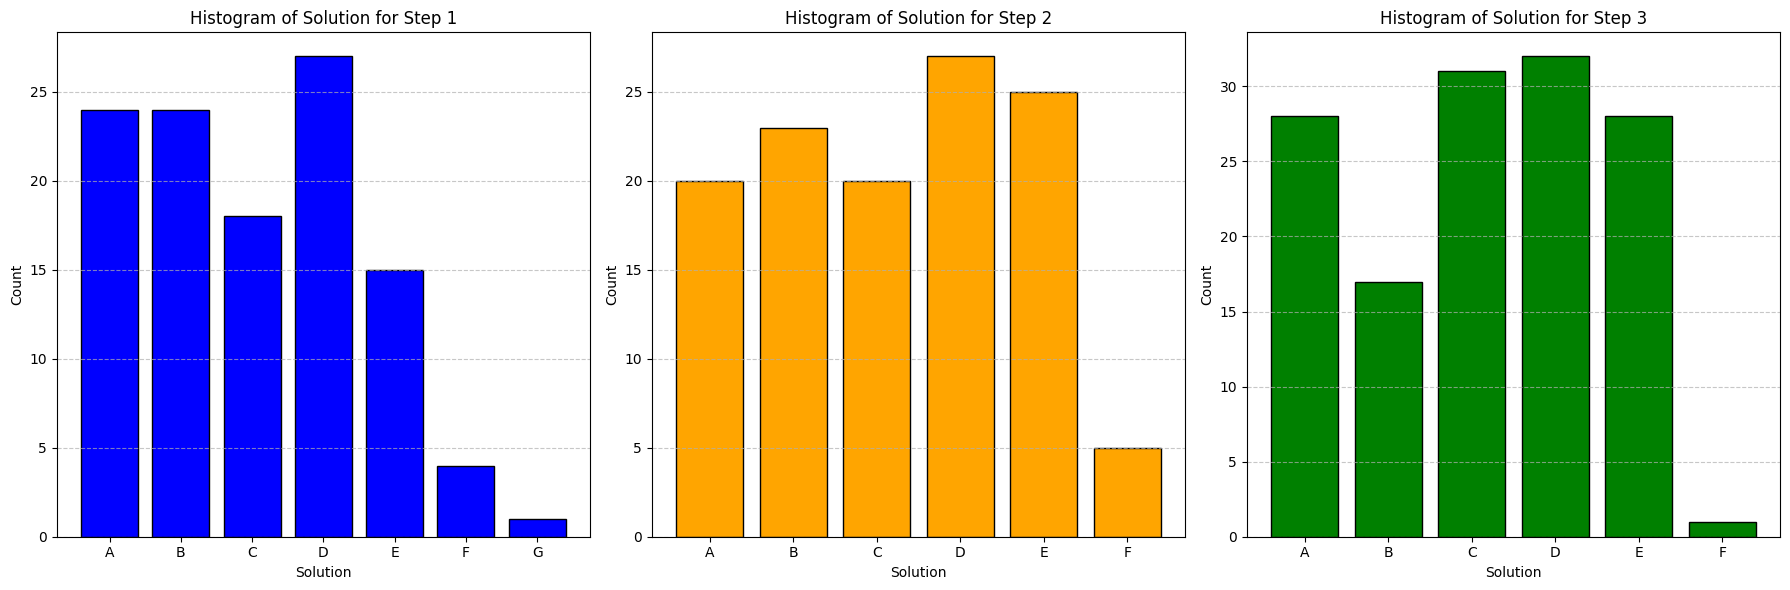

In [43]:
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np

solutions_by_step = defaultdict(list)

for question in questions_saved:
    step = question["step"]
    solution = question["solution"]
    if solution is None:
        continue
    solutions_by_step[step].append(solution)

colors = ["blue", "orange", "green"]
labels = [f"Step {i}" for i in range(1, 4)]

# Create a single figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot each histogram on its respective subplot
for step_idx, color, label, ax in zip(range(1, 4), colors, labels, axes):
    # Count occurrences of each unique solution (A, B, C, etc.)
    unique_solutions, counts = np.unique(solutions_by_step[step_idx], return_counts=True)

    ax.bar(unique_solutions, counts, color=color, edgecolor="black")

    ax.set_title(f"Histogram of Solution for {label}")
    ax.set_xlabel("Solution")
    ax.set_ylabel("Count")
    ax.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

Before we proceed to the evaluation we experiment with the questions in the evaluation dataset. Using the [all-mpnet-base-v2](https://huggingface.co/sentence-transformers/all-mpnet-base-v2) model, the questions are embedded in a 768 dimensional vector space.

In [28]:
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import matplotlib.pyplot as plt

model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")

sentences = [q["question"] for q in questions_saved]
steps = [q["step"] for q in questions_saved]

embeddings = model.encode(sentences)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

1_Pooling/config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

We can find the most similar questions to a given question by calculating pairwise cosine distances. You can try out question with id 110 for instance.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output

similarity_matrix = cosine_similarity(embeddings)

def find_k_most_similar(index, k):
    similarity_scores = similarity_matrix[index]

    # Exclude the question itself by setting its similarity to -1
    similarity_scores[index] = -1

    # Get the indices of the top k most similar questions
    top_k_indices = similarity_scores.argsort()[-k:][::-1]

    return [(similarity_scores[i], sentences[i], steps[i]) for i in top_k_indices]


def interactive_find_similar(index, k):
    most_similar_questions = find_k_most_similar(index, k)

    clear_output(wait=True)

    display(index_input, k_input, display_button)

    print(f"\nSelected Question:")
    print(f"Step: {steps[index]}, Question: {sentences[index]}")

    print("\nMost similar questions:")
    print(f"{'Step':<10}{'Similarity':<12}{'Question':<50}")
    print("-" * 80)
    for score, question, step in most_similar_questions:
        cleaned_question = question.strip().replace("\n", " ")
        print(f"{step:<10}{score:<12.4f}{cleaned_question:<50}")


# Create interactive widgets
index_input = widgets.IntSlider(value=0, min=0, max=len(sentences)-1, description="Question:")
k_input = widgets.IntSlider(value=5, min=1, max=10, description="k:")

# Button to display results
# The 200px is necessary to see the entire button text
display_button = widgets.Button(description="Show similar questions", layout=widgets.Layout(width="200px"))

def on_button_click(b):
    index = index_input.value
    k = k_input.value
    interactive_find_similar(index, k)

display_button.on_click(on_button_click)

# Display the widgets
display(index_input, k_input, display_button)

# Try question with id 110


IntSlider(value=110, description='Question:', max=369)

IntSlider(value=5, description='k:', max=10, min=1)

Button(description='Show similar questions', layout=Layout(width='200px'), style=ButtonStyle())


Selected Question:
Step: 1, Question: A 38-year-old woman comes to the clinic to discuss results of a biopsy specimen of a mass in the right breast obtained 1 week ago. She has no history of serious illness and takes no medications. Vital signs are within normal limits. Examination of the right breast shows a well-healing biopsy incision. The remainder of the examination discloses no abnormalities. Results of the biopsy specimen disclose ductal carcinoma in situ. The physician informs the patient he has some bad news to share and tells her the diagnosis. He explains her treatment options, including mastectomy, breast-conserving surgery, radiation therapy, chemotherapy, and any combination of these options. The patient appears afraid but listens attentively before responding, 'You're the doctor. My children are still little. Tell me what I should do.' In addition to expressing empathy, which of the following is the most appropriate physician response?

Top similar questions:
Step      

Furthermore, we can find the most similar question in the evaluation dataset to a user-provided question. For instance, try the question "Does the patient have a broken arm?"

In [44]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output
from sklearn.feature_extraction.text import TfidfVectorizer


def find_k_most_similar_to_user_question(user_question, k):
    user_question_embedding = model.encode([user_question])
    similarity_scores = cosine_similarity(user_question_embedding, embeddings).flatten()

    # Get the indices of the top k most similar questions
    # Note that the [::-1] reverses the order
    top_k_indices = similarity_scores.argsort()[-k:][::-1]

    return [(similarity_scores[i], sentences[i], steps[i]) for i in top_k_indices]


def interactive_find_similar_to_user_question(user_question, k):
    most_similar_questions = find_k_most_similar_to_user_question(user_question, k)

    clear_output(wait=True)

    display(question_input, k_input, display_button)

    print(f"\nYour question:")
    print(f"{user_question}")

    print("\nMost similar questions:")
    print(f"{'Step':<10}{'Similarity':<12}{'Question':<50}")
    print("-" * 80)
    for score, question, step in most_similar_questions:
        cleaned_question = question.strip().replace("\n", " ")
        print(f"{step:<10}{score:<12.4f}{cleaned_question:<50}")


# Create interactive widgets
question_input = widgets.Text(
    value="",
    placeholder="Type a question...",
    description="Question:",
    layout=widgets.Layout(width="70%")
)

k_input = widgets.IntSlider(value=5, min=1, max=10, description="k:")

# Button to display results
display_button = widgets.Button(description="Show similar questions", layout=widgets.Layout(width="200px"))

def on_button_click(b):
    user_question = question_input.value
    k = k_input.value
    interactive_find_similar_to_user_question(user_question, k)

display_button.on_click(on_button_click)

# Display the widgets
display(question_input, k_input, display_button)

Text(value='Does the patient have a broken arm?', description='Question:', layout=Layout(width='70%'), placeho…

IntSlider(value=5, description='k:', max=10, min=1)

Button(description='Show similar questions', layout=Layout(width='200px'), style=ButtonStyle())


Your question:
Does the patient have a broken arm?

Most similar questions:
Step      Similarity  Question                                          
--------------------------------------------------------------------------------
3         0.6613      A 35-year-old man is brought to the emergency department 30 minutes after a bicycle accident because of pain in his left arm. The patient is 183 cm (6 ft) tall and weighs 79 kg (175 lb); BMI is 24 kg/m2. Vital signs are temperature 37.0°C (98.6°F), pulse 75/min, respirations 16/min, and blood pressure 116/68 mm Hg. On arrival, the patient is awake and alert. Examination of the cervical spine shows no abnormalities. The left forearm is diffusely tender to palpation, and the patient is unable to extend his elbow. X-ray of the left forearm is shown. Which of the following is the most likely diagnosis?
1         0.6232      A 19-year-old man is admitted to the hospital 1 hour after he was involved in a motor vehicle collision in which he sus

Next, we visualize the embeddings. To do this, the embeddings are first projected to three dimensional space using Principal Component Analysis.

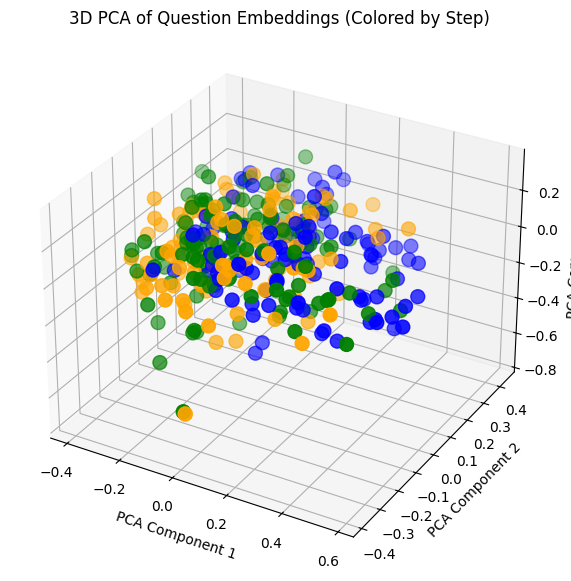

In [33]:
pca = PCA(n_components=3)
pca_embeddings = pca.fit_transform(embeddings)

# Plot the embeddings in 3D and color them according to the step
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

colors = ["blue", "orange", "green"]
step_colors = [colors[step-1] for step in steps]  # Color according to step (1, 2, or 3)

ax.scatter(pca_embeddings[:, 0], pca_embeddings[:, 1], pca_embeddings[:, 2],
           c=step_colors, marker="o", s=100)

ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_zlabel("PCA Component 3")
ax.set_title("3D PCA of Question Embeddings (Colored by Step)")

plt.show()

We can not observe a clear clustering of the questions into the three steps. Thus, we cluster the original embeddings using K-Means. However, K-Means does not tell us, which cluster corresponds to which step (or even that the clusters correspond to steps but lets ignore that). This problem is an instance of the well-known [assignment problem](https://en.wikipedia.org/wiki/Assignment_problem) that can be solved using the $\texttt{scipy.optimize.
linear_sum_assignment}$ function.

However, the [adjusted rand index (ARI)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.adjusted_rand_score.html), which is a value between -0.5 and 1.0 is 0.05 for the given clustering. A value close to 0 means that the labelling from the clustering is random. An ARI value of 1.0 means perfect match.

The [Normalized Mutual Information (NMI)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.normalized_mutual_info_score.html) is a number between 0 (no mutual information) and 1 (perfect correlation). The NMI score in our case is 0.06.

Both the ARI and NMI score indicate that the clustering is not good, which is confirmed by the confusion matrix.

Adjusted Rand Index (ARI): 0.05
Normalized Mutual Information (NMI): 0.06


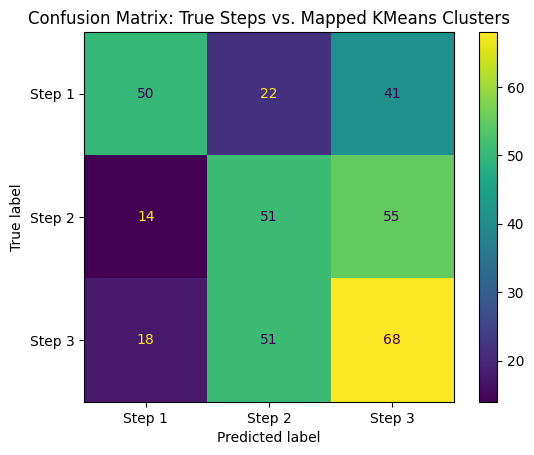

In [34]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from scipy.optimize import linear_sum_assignment
import numpy as np

kmeans = KMeans(n_clusters=3, random_state=0)
kmeans_labels = kmeans.fit_predict(embeddings)

true_labels = [step - 1 for step in steps]

# Create a confusion matrix
conf_matrix = confusion_matrix(true_labels, kmeans_labels)

# Find the best cluster to step mapping
row_ind, col_ind = linear_sum_assignment(-conf_matrix)  # Negative because we want to maximize agreement
mapping = {col: row for row, col in zip(row_ind, col_ind)}

# Map the predicted labels to the true labels
mapped_labels = [mapping[label] for label in kmeans_labels]

# Calculate performance metrics
ari = adjusted_rand_score(true_labels, mapped_labels)
nmi = normalized_mutual_info_score(true_labels, mapped_labels)

print(f"Adjusted Rand Index (ARI): {ari:.2f}")
print(f"Normalized Mutual Information (NMI): {nmi:.2f}")

# Plot the confusion matrix with the mapped labels
mapped_conf_matrix = confusion_matrix(true_labels, mapped_labels)
ConfusionMatrixDisplay(mapped_conf_matrix, display_labels=["Step 1", "Step 2", "Step 3"]).plot()
plt.title("Confusion Matrix: True Steps vs. Mapped KMeans Clusters")
plt.show()


### Evaluation Code
We proceed with the evaluation of the LLMs using the USMLE dataset.

In [12]:
# The code was adapted from https://github.com/kbressem/medAlpaca/blob/main/eval/eval_usmle.py
def format_question(d):
    question = d["question"]
    options = d["options"]
    for k, v in options.items():
        question += f"\n{k}: {v}"
    return question

def strip_special_chars(input_str):
    "Remove special characters from string start/end"
    if not input_str:
        return input_str

    start_index = 0
    end_index = len(input_str) - 1

    while start_index < len(input_str) and input_str[start_index] not in string.ascii_letters + string.digits:
        start_index += 1

    while end_index >= 0 and input_str[end_index] not in string.ascii_letters + string.digits:
        end_index -= 1

    if start_index <= end_index:
        return input_str[start_index:end_index + 1]
    else:
        return ""

def starts_with_capital_letter(input_str):
    """
    The answers should start like 'A: ' or 'A. ' or 'A '
    """
    if not isinstance(input_str, str):
      return False

    # We use a different regex since we also want to match if there is nothing after the capital letter
    pattern = r"^[A-Z](:|\.|)( .+|$)"
    return bool(re.match(pattern, input_str))

def extract_option(response):
    # The model often provides additional characters than just the option (e.g. reason)
    pattern = r"^[A-Z]"
    match = re.search(pattern, response)

    return match.group(0) if match else None

def add_solutions_to_json(output_json_path, question_json_path, solution_json_path):
    with open(solution_json_path) as sol_fp:
        solutions = json.load(sol_fp)

    with open(question_json_path) as fp:
        questions = json.load(fp)

    questions_included = []

    for index, question in enumerate(questions):
        # We only consider questions without an image
        if question.get("image") or question.get("image_url"):
          continue
        solution_key = str(index + 1)
        if solution_key in solutions:
            question["solution"] = solutions[solution_key]
            questions_included.append(question)
        else:
            question["solution"] = None


    with open(output_json_path, "w") as out_fp:
        json.dump(questions_included, out_fp)

In [16]:
# The code was adapted from https://github.com/kbressem/medAlpaca/blob/main/eval/eval_usmle.py

import re
import json
import string
from transformers import pipeline
from tqdm.autonotebook import tqdm

def generate_evaluation_json(model, tokenizer, model_name, ntries = 5):
  pipe = pipeline("text-generation", model=model, tokenizer=tokenizer, return_full_text=False)
  for step_idx in range(1,4):
    question_json = f"./eval/step{step_idx}.json"
    solution_json = f"./eval/step{step_idx}_solutions.json"
    output_json = f"./eval/step{step_idx}_output_{model_name}.json"

    add_solutions_to_json(output_json, question_json, solution_json)

    with open(output_json) as fp:
        questions = json.load(fp)

    pbar = tqdm(questions)
    pbar.set_description_str(f"Evaluating USMLE Step {step_idx}")

    answers = []

    for i, question in enumerate(pbar):
        for j in range(ntries):
            formatted_question = format_question(question)
            input_text = f"<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nAnswer this multiple choice question with a single capital letter. No justification required.<|eot_id|><|start_header_id|>user<|end_header_id|>\n\n{formatted_question}<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\nThe Answer to the question is:"

            response = pipe(input_text, max_new_tokens=50, num_return_sequences=1, pad_token_id=tokenizer.pad_token_id)[0]["generated_text"]

            response = strip_special_chars(response)

            if starts_with_capital_letter(response):
                pbar.set_postfix_str(f"")
                break
            else:
                pbar.set_postfix_str(f"Output not satisfactoy, retrying {j+1}/{ntries}")

        question["modelAnswer"] = extract_option(response)
        answers.append(question)

        with open(output_json, "w+") as fp:
            json.dump(answers, fp)

In [14]:
def evaluate_step(output_json_path):
  number_correct = 0
  with open(output_json_path) as fp:
      step = json.load(fp)
      for question in step:
        if question["modelAnswer"] == question["solution"]:
          number_correct += 1
  return number_correct / len(step)

def print_accuracy_per_step(model_name):
  step1_output_json = f"./eval/step{1}_output_{model_name}.json"
  step2_output_json = f"./eval/step{2}_output_{model_name}.json"
  step3_output_json = f"./eval/step{3}_output_{model_name}.json"

  acc_step1 = evaluate_step(step1_output_json)
  acc_step2 = evaluate_step(step2_output_json)
  acc_step3 = evaluate_step(step3_output_json)

  print(f"{model_name:} Step 1 accuracy {acc_step1}")
  print(f"{model_name:} Step 2 accuracy {acc_step2}")
  print(f"{model_name:} Step 3 accuracy {acc_step3}")

### Evaluating the models

First the Llama-3.2-1B-Instruct model is evaluated.

In [18]:
llama_model_name = "Llama-3.2-1B-Instruct"  # Can not use real model name because of "/" in name
generate_evaluation_json(llama_model, llama_tokenizer, llama_model_name)
print_accuracy_per_step(llama_model_name)

Device set to use cuda:0


  0%|          | 0/113 [00:00<?, ?it/s]

  0%|          | 0/120 [00:00<?, ?it/s]

  0%|          | 0/137 [00:00<?, ?it/s]

Llama-3.2-1B-Instruct Step 1 accuracy 0.2831858407079646
Llama-3.2-1B-Instruct Step 2 accuracy 0.44166666666666665
Llama-3.2-1B-Instruct Step 3 accuracy 0.43795620437956206


This result seems to be reasonable when comparing it to the findings in [this article](https://ai-assisted-healthcare.com/2024/04/21/llama3-70b-performs-on-par-with-gpt-4-turbo-on-answering-usmle-questions/), although they considered Llama3-8B and Llama3-70B.

Next, the Llama-3.2-1B-Instruct model finetuned on the medical flashcards dataset is evaluated.

In [19]:
finetuned_model_name = llama_model_name + "-Finetuned"
generate_evaluation_json(llama_finetuned_model, llama_finetuned_tokenizer, finetuned_model_name)
print_accuracy_per_step(finetuned_model_name)

Device set to use cuda:0


  0%|          | 0/113 [00:00<?, ?it/s]

  0%|          | 0/120 [00:00<?, ?it/s]

  0%|          | 0/137 [00:00<?, ?it/s]

Llama-3.2-1B-Instruct-Finetuned Step 1 accuracy 0.24778761061946902
Llama-3.2-1B-Instruct-Finetuned Step 2 accuracy 0.36666666666666664
Llama-3.2-1B-Instruct-Finetuned Step 3 accuracy 0.5255474452554745


We can compare the performance to the results in the medAlpaca paper. The below table shows the performance of different models as reported in the medAlpaca paper.

In [ ]:
import pandas as pd

# The data is taken from the table in the medAlpaca paper
df = pd.DataFrame([
    {"Model": "LLaMA 7b [15]", "Step1": 0.198, "Step2": 0.202, "Step3": 0.203},
    {"Model": "Alpaca 7b naive [11]", "Step1": 0.275, "Step2": 0.266, "Step3": 0.293},
    {"Model": "Alpaca 7b LoRA", "Step1": 0.220, "Step2": 0.138, "Step3": 0.252},
    {"Model": "MedAlpaca 7b", "Step1": 0.297, "Step2": 0.312, "Step3": 0.398},
    {"Model": "MedAlpaca 7b LoRA", "Step1": 0.231, "Step2": 0.202, "Step3": 0.179},
    {"Model": "MedAlpaca 7b LoRA 8bit", "Step1": 0.231, "Step2": 0.241, "Step3": 0.211},
    {"Model": "ChatDoctor (7b) [10]", "Step1": 0.187, "Step2": 0.185, "Step3": 0.148},
    {"Model": "LLaMA 13b [15]", "Step1": 0.222, "Step2": 0.248, "Step3": 0.276},
    {"Model": "Alpaca 13b naive", "Step1": 0.319, "Step2": 0.312, "Step3": 0.301},
    {"Model": "MedAlpaca 13b", "Step1": 0.473, "Step2": 0.477, "Step3": 0.602},
    {"Model": "MedAlpaca 13b LoRA", "Step1": 0.250, "Step2": 0.255, "Step3": 0.255},
    {"Model": "MedAlpaca 13b LoRA 8bit", "Step1": 0.189, "Step2": 0.303, "Step3": 0.289}
])
display(df)

,Model,Step1,Step2,Step3
0,LLaMA 7b [15],0.198,0.202,0.203
1,Alpaca 7b naive [11],0.275,0.266,0.293
2,Alpaca 7b LoRA,0.220,0.138,0.252
3,MedAlpaca 7b,0.297,0.312,0.398
4,MedAlpaca 7b LoRA,0.231,0.202,0.179
5,MedAlpaca 7b LoRA 8bit,0.231,0.241,0.211
6,ChatDoctor (7b) [10],0.187,0.185,0.148
7,LLaMA 13b [15],0.222,0.248,0.276
8,Alpaca 13b naive,0.319,0.312,0.301
9,MedAlpaca 13b,0.473,0.477,0.602
